Samples, Features: (569, 30)
Class balance:
 diagnosis
1    0.627417
0    0.372583
Name: proportion, dtype: float64

Best hyperparameters found: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation ROC-AUC: 0.9892
Out-of-bag score: 0.9648

----- Random Forest Performance on Test Set -----
Accuracy  : 0.9441
Precision : 0.9457
Recall    : 0.9667
F1 Score  : 0.9560
ROC-AUC   : 0.9945

Confusion Matrix:
 [[48  5]
 [ 3 87]]

Detailed Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.91      0.92        53
           1       0.95      0.97      0.96        90

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143



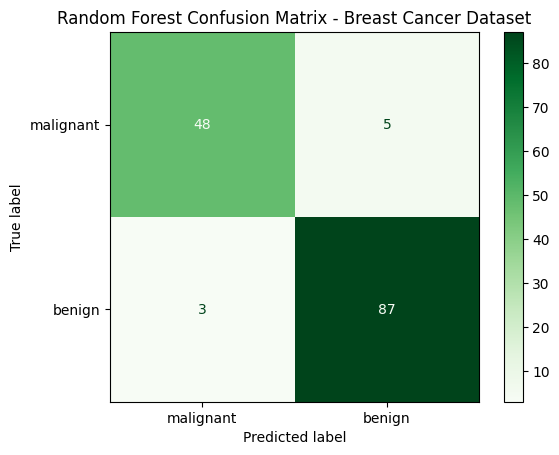

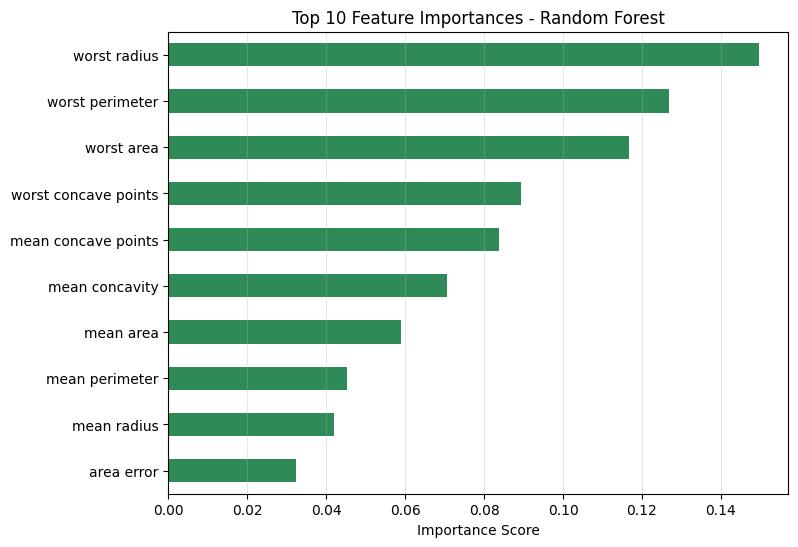

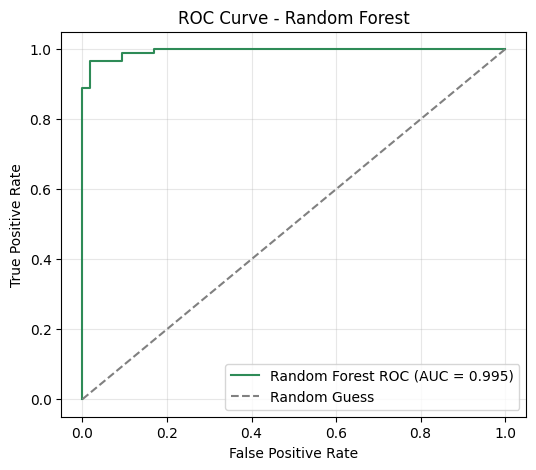

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

cancer_data = load_breast_cancer()
features_df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
target_series = pd.Series(cancer_data.target, name="diagnosis")

print("Samples, Features:", features_df.shape)
print("Class balance:\n", target_series.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    features_df, target_series, test_size=0.25, random_state=13, stratify=target_series
)

forest_clf = RandomForestClassifier(random_state=13, n_jobs=-1, oob_score=True)

tuning_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 8, 15],
    "min_samples_split": [2, 4],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=forest_clf,
    param_grid=tuning_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)
print("\nBest hyperparameters found:", grid_search.best_params_)
print("Best cross-validation ROC-AUC:", round(grid_search.best_score_, 4))

final_forest = grid_search.best_estimator_
final_forest.fit(X_train, y_train)
print("Out-of-bag score:", round(final_forest.oob_score_, 4))

y_hat = final_forest.predict(X_test)
y_prob_pos = final_forest.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_hat)
test_precision = precision_score(y_test, y_hat, zero_division=0)
test_recall = recall_score(y_test, y_hat)
test_f1 = f1_score(y_test, y_hat)
test_auc = roc_auc_score(y_test, y_prob_pos)
conf_mat = confusion_matrix(y_test, y_hat)

print("\n----- Random Forest Performance on Test Set -----")
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_auc:.4f}")
print("\nConfusion Matrix:\n", conf_mat)
print("\nDetailed Classification Report:\n", classification_report(y_test, y_hat, zero_division=0))

disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=cancer_data.target_names)
disp.plot(cmap="Greens")
plt.title("Random Forest Confusion Matrix - Breast Cancer Dataset")
plt.show()

feat_importance = pd.Series(final_forest.feature_importances_, index=features_df.columns)
top_features = feat_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
top_features[::-1].plot(kind="barh", color="seagreen")
plt.xlabel("Importance Score")
plt.title("Top 10 Feature Importances - Random Forest")
plt.grid(axis="x", alpha=0.3)
plt.show()

fpr_vals, tpr_vals, roc_thresh = roc_curve(y_test, y_prob_pos)
plt.figure(figsize=(6, 5))
plt.plot(fpr_vals, tpr_vals, color='seagreen', label=f"Random Forest ROC (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()